# 🏗️ Full Portfolio Dashboard — 60 builds, one view

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/mini-saas-products/portfolio-dashboard/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=mini-saas-products/portfolio-dashboard/demo.ipynb)

**Pain point:** *"Showcase all 60 projects in one view."*

The final build of Portfolio 1: a dashboard that parses the portfolio's own TRACKER.md and turns 60 days of building into stats, a burn-up chart, and a linked catalog. The portfolio showcases itself.

**What this notebook covers:**
1. The parser — TRACKER.md lines into structured builds
2. Portfolio stats — pace, streaks, busiest day
3. The burn-up chart — actual vs. 1-build-per-day pace
4. Product line breakdown
5. The full linked catalog


## Step 1 — The parser

Two regexes do the work: one matches month headings (`## Month N: Product Line`), one matches build lines (`- [x] Day N — slug: Title (date)`). Each build becomes a dataclass with its product line, folder, completion date, and GitHub URL.

In [1]:
from __future__ import annotations

import re
from dataclasses import dataclass
from datetime import date, timedelta
from typing import Dict, List, Optional

REPO_URL = "https://github.com/phoebefu6/phoebe-the-builder"

LINE_FOLDERS: Dict[str, str] = {
    "Data Infrastructure Toolkit": "data-infra-toolkit",
    "Business Automation Suite": "automation-suite",
    "Analytics Accelerator": "analytics-accelerator",
    "Document Intelligence": "document-intelligence",
    "AI Agent Workshop": "ai-agent-workshop",
    "Mini SaaS Products": "mini-saas-products",
}

_HEADING = re.compile(r"^#+\s*Month\s+(\d+):\s*([^(\n]+?)(?:\s*\(([\w-]+)/?\))?\s*$")
_ITEM = re.compile(
    r"^- \[(?P<done>[x ])\] Day (?P<day>\d+) — (?P<slug>[\w-]+): (?P<title>[^(\n]+?)(?:\s*\((?P<date>\d{4}-\d{2}-\d{2})\))?\s*$"
)


@dataclass
class Build:
    day: int
    slug: str
    title: str
    product_line: str
    folder: str
    done: bool
    completed: Optional[date] = None

    @property
    def url(self) -> str:
        return f"{REPO_URL}/tree/main/{self.folder}/{self.slug}"


def parse_tracker(text: str) -> List[Build]:
    builds: List[Build] = []
    line_name, folder = "Unknown", "unknown"
    for raw in text.splitlines():
        heading = _HEADING.match(raw.strip())
        if heading:
            line_name = heading.group(2).strip()
            folder = heading.group(3) or LINE_FOLDERS.get(line_name, line_name.lower().replace(" ", "-"))
            continue
        item = _ITEM.match(raw.strip())
        if item:
            builds.append(Build(
                day=int(item.group("day")),
                slug=item.group("slug"),
                title=item.group("title").strip(),
                product_line=line_name,
                folder=folder,
                done=item.group("done") == "x",
                completed=date.fromisoformat(item.group("date")) if item.group("date") else None,
            ))
    return builds


def portfolio_stats(builds: List[Build]) -> Dict[str, object]:
    done = [b for b in builds if b.done and b.completed]
    if not done:
        return {"total": len(builds), "completed": 0}
    dates = sorted(b.completed for b in done)
    start, end = dates[0], dates[-1]
    per_day: Dict[date, int] = {}
    for d in dates:
        per_day[d] = per_day.get(d, 0) + 1
    busiest = max(per_day.items(), key=lambda kv: kv[1])
    gaps = [(b - a).days for a, b in zip(dates, dates[1:]) if (b - a).days > 1]
    calendar_days = (end - start).days + 1
    by_line: Dict[str, Dict[str, int]] = {}
    for b in builds:
        row = by_line.setdefault(b.product_line, {"done": 0, "total": 0})
        row["total"] += 1
        row["done"] += int(b.done)
    return {
        "total": len(builds),
        "completed": len(done),
        "start": start,
        "end": end,
        "calendar_days": calendar_days,
        "builds_per_calendar_day": round(len(done) / calendar_days, 2),
        "busiest_day": busiest,
        "active_days": len(per_day),
        "longest_gap_days": max(gaps) if gaps else 0,
        "by_line": by_line,
    }


def cumulative_timeline(builds: List[Build]) -> List[Dict[str, object]]:
    """Daily cumulative completed count from first to last completion date."""
    done = sorted((b for b in builds if b.done and b.completed), key=lambda b: b.completed)
    if not done:
        return []
    start, end = done[0].completed, done[-1].completed
    out: List[Dict[str, object]] = []
    idx, total = 0, 0
    day = start
    while day <= end:
        while idx < len(done) and done[idx].completed == day:
            total += 1
            idx += 1
        out.append({"date": day, "cumulative": total, "ideal": min((day - start).days + 1, len(done))})
        day += timedelta(days=1)
    return out


def to_markdown_table(builds: List[Build]) -> str:
    lines = ["| Day | Project | Product line | Status | Link |", "|---|---|---|---|---|"]
    for b in sorted(builds, key=lambda x: x.day):
        status = f"✅ {b.completed}" if b.done else "⬜ planned"
        lines.append(f"| {b.day} | {b.title} | {b.product_line} | {status} | [{b.slug}]({b.url}) |")
    return "\n".join(lines)


## Step 2 — Load the tracker

A snapshot of TRACKER.md as of completion day (2026-07-11) is embedded below, so this notebook runs anywhere. Running inside the repo? Swap in `open('../../TRACKER.md').read()` for live data.

In [2]:
TRACKER = """# FDE Portfolio Tracker

**Started:** 2026-06-07
**Current Streak:** 60 days
**Total Completed:** 60 / 120 (Portfolio 1: 60/60 ✅ COMPLETE · Portfolio 2: 0/60)
**Portfolio 2 plan:** see [PORTFOLIO-2-PLAN.md](PORTFOLIO-2-PLAN.md) for build details (Days 61-120)

---

## Month 1: Data Infrastructure Toolkit

- [x] Day 1 — csv-loader: CSV to PostgreSQL Loader (2026-06-07)
- [x] Day 2 — schema-diff: Schema Diff Tool (2026-06-08)
- [x] Day 3 — api-warehouse-connector: API to Warehouse Connector (2026-06-09)
- [x] Day 4 — data-freshness-monitor: Data Freshness Monitor (2026-06-10)
- [x] Day 5 — pii-detector: PII Detector and Masker (2026-06-11)
- [x] Day 6 — erd-generator: ERD Generator from SQL (2026-06-12)
- [x] Day 7 — dbt-model-generator: dbt Model Generator (2026-06-14)
- [x] Day 8 — data-lineage-viz: Data Lineage Visualizer (2026-06-17)
- [x] Day 9 — gx-config-generator: Great Expectations Config Generator (2026-06-19)
- [x] Day 10 — db-health-dashboard: Database Health Dashboard (2026-06-20)

## Month 2: Business Automation Suite

- [x] Day 11 — csv-cleaner: CSV Cleaner (2026-06-20)
- [x] Day 12 — json-validator: JSON Schema Validator (2026-06-20)
- [x] Day 13 — auto-readme: Auto-README Generator (2026-06-20)
- [x] Day 14 — cron-monitor: Cron Job Monitor (2026-06-20)
- [x] Day 15 — env-checker: Environment Variable Checker (2026-06-20)
- [x] Day 16 — log-parser: Log Parser and Alerter (2026-06-20)
- [x] Day 17 — sql-formatter: SQL Query Formatter (2026-06-20)
- [x] Day 18 — md-to-pdf: Markdown to PDF Report (2026-06-21)
- [x] Day 19 — duplicate-finder: Duplicate File Finder (2026-06-21)
- [x] Day 20 — standup-bot: Daily Standup Bot (2026-06-21)

## Month 3: Analytics Accelerator

- [x] Day 21 — auto-eda: Auto-EDA Dashboard (2026-06-21)
- [x] Day 22 — kpi-tracker: KPI Tracker (2026-06-24)
- [x] Day 23 — ab-test-calc: A/B Test Calculator (2026-06-24)
- [x] Day 24 — survey-analyzer: Survey Results Analyzer (2026-06-25)
- [x] Day 25 — customer-segments: Customer Segmentation Tool (2026-06-25)
- [x] Day 26 — churn-predictor: Churn Predictor (2026-06-25)
- [x] Day 27 — sales-forecast: Sales Forecast Dashboard (2026-06-26)
- [x] Day 28 — data-quality-scorecard: Data Quality Scorecard (2026-06-26)
- [x] Day 29 — funnel-analyzer: Funnel Analyzer (2026-06-26)
- [x] Day 30 — cohort-analysis: Cohort Analysis Tool (2026-06-28)

## Month 4: Document Intelligence

- [x] Day 31 — pdf-qa-bot: PDF Q&A Bot (2026-06-28)
- [x] Day 32 — meeting-summarizer: Meeting Notes Summarizer (2026-06-28)
- [x] Day 33 — contract-extractor: Contract Clause Extractor (2026-06-30)
- [x] Day 34 — faq-generator: FAQ Generator from Docs (2026-06-30)
- [x] Day 35 — semantic-search: Semantic Search Engine (2026-06-30)
- [x] Day 36 — resume-screener: Resume Screener (2026-06-30)
- [x] Day 37 — competitive-intel: Competitive Intel Summarizer (2026-06-30)
- [x] Day 38 — data-dict-gen: Data Dictionary Generator (2026-06-30)
- [x] Day 39 — compliance-checker: Compliance Checker (2026-06-30)
- [x] Day 40 — knowledge-base: Knowledge Base Builder (2026-06-30)

## Month 5: AI Agent Workshop

- [x] Day 41 — email-agent: Email Draft Agent (2026-07-04)
- [x] Day 42 — code-review-agent: Code Review Agent (2026-07-04)
- [x] Day 43 — pipeline-monitor-agent: Data Pipeline Monitor Agent (2026-07-04)
- [x] Day 44 — ticket-router: Customer Ticket Router (2026-07-05)
- [x] Day 45 — onboarding-agent: Onboarding Checklist Agent (2026-07-06)
- [x] Day 46 — incident-agent: Incident Response Agent (2026-07-07)
- [x] Day 47 — report-agent: Report Generation Agent (2026-07-07)
- [x] Day 48 — slack-qa-agent: Slack Q&A Agent (2026-07-07)
- [x] Day 49 — model-drift-detector: Model Drift Detector (2026-07-07)
- [x] Day 50 — agent-eval-dashboard: Agent Evaluation Dashboard (2026-07-07)

## Month 6: Mini SaaS Products

- [x] Day 51 — idea-validator: Startup Idea Validator (2026-07-07)
- [x] Day 52 — feedback-analyzer: User Feedback Analyzer (2026-07-07)
- [x] Day 53 — feature-prioritizer: Feature Prioritization Tool (2026-07-07)
- [x] Day 54 — retro-generator: Sprint Retrospective Generator (2026-07-07)
- [x] Day 55 — okr-tracker: OKR Tracker and Advisor (2026-07-07)
- [x] Day 56 — roadmap-viz: Product Roadmap Visualizer (2026-07-07)
- [x] Day 57 — user-story-gen: User Story Generator (2026-07-11)
- [x] Day 58 — accessibility-checker: Accessibility Checker (2026-07-11)
- [x] Day 59 — privacy-policy-gen: Privacy Policy Generator (2026-07-11)
- [x] Day 60 — portfolio-dashboard: Full Portfolio Dashboard (2026-07-11)"""

builds = [b for b in parse_tracker(TRACKER) if b.day <= 60]
print(f"parsed {len(builds)} builds, {sum(b.done for b in builds)} completed")

parsed 60 builds, 60 completed


## Step 3 — Portfolio stats

In [3]:
stats = portfolio_stats(builds)
print(f"Builds shipped:        {stats['completed']}/{stats['total']}")
print(f"Span:                  {stats['start']} → {stats['end']}  ({stats['calendar_days']} calendar days)")
print(f"Pace:                  {stats['builds_per_calendar_day']} builds per calendar day")
print(f"Active build days:     {stats['active_days']}")
print(f"Busiest day:           {stats['busiest_day'][0]} ({stats['busiest_day'][1]} builds shipped)")
print(f"Longest gap:           {stats['longest_gap_days']} days")

Builds shipped:        60/60
Span:                  2026-06-07 → 2026-07-11  (35 calendar days)
Pace:                  1.71 builds per calendar day
Active build days:     21
Busiest day:           2026-07-07 (11 builds shipped)
Longest gap:           4 days


## Step 4 — Burn-up chart + product lines

Left: cumulative builds against the ideal 1-per-day line — visible sprints (11 builds on 2026-07-07) and pauses. Right: all six product lines at 10/10.

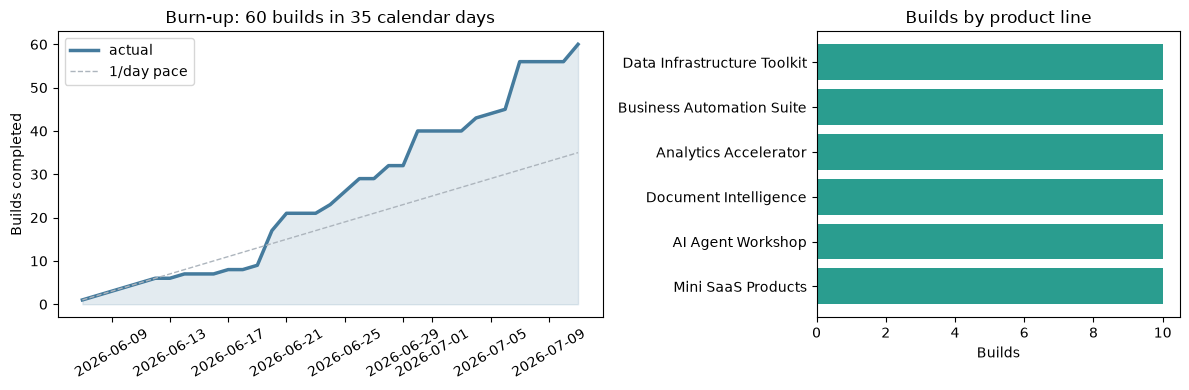

In [4]:
import matplotlib.pyplot as plt

tl = cumulative_timeline(builds)
dates = [p["date"] for p in tl]
actual = [p["cumulative"] for p in tl]
ideal = [p["ideal"] for p in tl]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={"width_ratios": [3, 2]})
ax1.plot(dates, actual, color="#457b9d", linewidth=2.5, label="actual")
ax1.plot(dates, ideal, color="#adb5bd", linestyle="--", linewidth=1, label="1/day pace")
ax1.fill_between(dates, actual, alpha=0.15, color="#457b9d")
ax1.set_title("Burn-up: 60 builds in 35 calendar days")
ax1.set_ylabel("Builds completed")
ax1.legend()
ax1.tick_params(axis="x", rotation=30)

lines = list(stats["by_line"].items())
ax2.barh([k for k, _ in lines], [v["done"] for _, v in lines], color="#2a9d8f")
ax2.set_title("Builds by product line")
ax2.set_xlabel("Builds")
ax2.invert_yaxis()

fig.tight_layout()
fig.savefig("portfolio_burnup.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 5 — The full catalog

Every build, linked to its folder in the repo.

In [5]:
from IPython.display import Markdown
Markdown(to_markdown_table(builds))

| Day | Project | Product line | Status | Link |
|---|---|---|---|---|
| 1 | CSV to PostgreSQL Loader | Data Infrastructure Toolkit | ✅ 2026-06-07 | [csv-loader](https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-infra-toolkit/csv-loader) |
| 2 | Schema Diff Tool | Data Infrastructure Toolkit | ✅ 2026-06-08 | [schema-diff](https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-infra-toolkit/schema-diff) |
| 3 | API to Warehouse Connector | Data Infrastructure Toolkit | ✅ 2026-06-09 | [api-warehouse-connector](https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-infra-toolkit/api-warehouse-connector) |
| 4 | Data Freshness Monitor | Data Infrastructure Toolkit | ✅ 2026-06-10 | [data-freshness-monitor](https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-infra-toolkit/data-freshness-monitor) |
| 5 | PII Detector and Masker | Data Infrastructure Toolkit | ✅ 2026-06-11 | [pii-detector](https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-infra-toolkit/pii-detector) |
| 6 | ERD Generator from SQL | Data Infrastructure Toolkit | ✅ 2026-06-12 | [erd-generator](https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-infra-toolkit/erd-generator) |
| 7 | dbt Model Generator | Data Infrastructure Toolkit | ✅ 2026-06-14 | [dbt-model-generator](https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-infra-toolkit/dbt-model-generator) |
| 8 | Data Lineage Visualizer | Data Infrastructure Toolkit | ✅ 2026-06-17 | [data-lineage-viz](https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-infra-toolkit/data-lineage-viz) |
| 9 | Great Expectations Config Generator | Data Infrastructure Toolkit | ✅ 2026-06-19 | [gx-config-generator](https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-infra-toolkit/gx-config-generator) |
| 10 | Database Health Dashboard | Data Infrastructure Toolkit | ✅ 2026-06-20 | [db-health-dashboard](https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-infra-toolkit/db-health-dashboard) |
| 11 | CSV Cleaner | Business Automation Suite | ✅ 2026-06-20 | [csv-cleaner](https://github.com/phoebefu6/phoebe-the-builder/tree/main/automation-suite/csv-cleaner) |
| 12 | JSON Schema Validator | Business Automation Suite | ✅ 2026-06-20 | [json-validator](https://github.com/phoebefu6/phoebe-the-builder/tree/main/automation-suite/json-validator) |
| 13 | Auto-README Generator | Business Automation Suite | ✅ 2026-06-20 | [auto-readme](https://github.com/phoebefu6/phoebe-the-builder/tree/main/automation-suite/auto-readme) |
| 14 | Cron Job Monitor | Business Automation Suite | ✅ 2026-06-20 | [cron-monitor](https://github.com/phoebefu6/phoebe-the-builder/tree/main/automation-suite/cron-monitor) |
| 15 | Environment Variable Checker | Business Automation Suite | ✅ 2026-06-20 | [env-checker](https://github.com/phoebefu6/phoebe-the-builder/tree/main/automation-suite/env-checker) |
| 16 | Log Parser and Alerter | Business Automation Suite | ✅ 2026-06-20 | [log-parser](https://github.com/phoebefu6/phoebe-the-builder/tree/main/automation-suite/log-parser) |
| 17 | SQL Query Formatter | Business Automation Suite | ✅ 2026-06-20 | [sql-formatter](https://github.com/phoebefu6/phoebe-the-builder/tree/main/automation-suite/sql-formatter) |
| 18 | Markdown to PDF Report | Business Automation Suite | ✅ 2026-06-21 | [md-to-pdf](https://github.com/phoebefu6/phoebe-the-builder/tree/main/automation-suite/md-to-pdf) |
| 19 | Duplicate File Finder | Business Automation Suite | ✅ 2026-06-21 | [duplicate-finder](https://github.com/phoebefu6/phoebe-the-builder/tree/main/automation-suite/duplicate-finder) |
| 20 | Daily Standup Bot | Business Automation Suite | ✅ 2026-06-21 | [standup-bot](https://github.com/phoebefu6/phoebe-the-builder/tree/main/automation-suite/standup-bot) |
| 21 | Auto-EDA Dashboard | Analytics Accelerator | ✅ 2026-06-21 | [auto-eda](https://github.com/phoebefu6/phoebe-the-builder/tree/main/analytics-accelerator/auto-eda) |
| 22 | KPI Tracker | Analytics Accelerator | ✅ 2026-06-24 | [kpi-tracker](https://github.com/phoebefu6/phoebe-the-builder/tree/main/analytics-accelerator/kpi-tracker) |
| 23 | A/B Test Calculator | Analytics Accelerator | ✅ 2026-06-24 | [ab-test-calc](https://github.com/phoebefu6/phoebe-the-builder/tree/main/analytics-accelerator/ab-test-calc) |
| 24 | Survey Results Analyzer | Analytics Accelerator | ✅ 2026-06-25 | [survey-analyzer](https://github.com/phoebefu6/phoebe-the-builder/tree/main/analytics-accelerator/survey-analyzer) |
| 25 | Customer Segmentation Tool | Analytics Accelerator | ✅ 2026-06-25 | [customer-segments](https://github.com/phoebefu6/phoebe-the-builder/tree/main/analytics-accelerator/customer-segments) |
| 26 | Churn Predictor | Analytics Accelerator | ✅ 2026-06-25 | [churn-predictor](https://github.com/phoebefu6/phoebe-the-builder/tree/main/analytics-accelerator/churn-predictor) |
| 27 | Sales Forecast Dashboard | Analytics Accelerator | ✅ 2026-06-26 | [sales-forecast](https://github.com/phoebefu6/phoebe-the-builder/tree/main/analytics-accelerator/sales-forecast) |
| 28 | Data Quality Scorecard | Analytics Accelerator | ✅ 2026-06-26 | [data-quality-scorecard](https://github.com/phoebefu6/phoebe-the-builder/tree/main/analytics-accelerator/data-quality-scorecard) |
| 29 | Funnel Analyzer | Analytics Accelerator | ✅ 2026-06-26 | [funnel-analyzer](https://github.com/phoebefu6/phoebe-the-builder/tree/main/analytics-accelerator/funnel-analyzer) |
| 30 | Cohort Analysis Tool | Analytics Accelerator | ✅ 2026-06-28 | [cohort-analysis](https://github.com/phoebefu6/phoebe-the-builder/tree/main/analytics-accelerator/cohort-analysis) |
| 31 | PDF Q&A Bot | Document Intelligence | ✅ 2026-06-28 | [pdf-qa-bot](https://github.com/phoebefu6/phoebe-the-builder/tree/main/document-intelligence/pdf-qa-bot) |
| 32 | Meeting Notes Summarizer | Document Intelligence | ✅ 2026-06-28 | [meeting-summarizer](https://github.com/phoebefu6/phoebe-the-builder/tree/main/document-intelligence/meeting-summarizer) |
| 33 | Contract Clause Extractor | Document Intelligence | ✅ 2026-06-30 | [contract-extractor](https://github.com/phoebefu6/phoebe-the-builder/tree/main/document-intelligence/contract-extractor) |
| 34 | FAQ Generator from Docs | Document Intelligence | ✅ 2026-06-30 | [faq-generator](https://github.com/phoebefu6/phoebe-the-builder/tree/main/document-intelligence/faq-generator) |
| 35 | Semantic Search Engine | Document Intelligence | ✅ 2026-06-30 | [semantic-search](https://github.com/phoebefu6/phoebe-the-builder/tree/main/document-intelligence/semantic-search) |
| 36 | Resume Screener | Document Intelligence | ✅ 2026-06-30 | [resume-screener](https://github.com/phoebefu6/phoebe-the-builder/tree/main/document-intelligence/resume-screener) |
| 37 | Competitive Intel Summarizer | Document Intelligence | ✅ 2026-06-30 | [competitive-intel](https://github.com/phoebefu6/phoebe-the-builder/tree/main/document-intelligence/competitive-intel) |
| 38 | Data Dictionary Generator | Document Intelligence | ✅ 2026-06-30 | [data-dict-gen](https://github.com/phoebefu6/phoebe-the-builder/tree/main/document-intelligence/data-dict-gen) |
| 39 | Compliance Checker | Document Intelligence | ✅ 2026-06-30 | [compliance-checker](https://github.com/phoebefu6/phoebe-the-builder/tree/main/document-intelligence/compliance-checker) |
| 40 | Knowledge Base Builder | Document Intelligence | ✅ 2026-06-30 | [knowledge-base](https://github.com/phoebefu6/phoebe-the-builder/tree/main/document-intelligence/knowledge-base) |
| 41 | Email Draft Agent | AI Agent Workshop | ✅ 2026-07-04 | [email-agent](https://github.com/phoebefu6/phoebe-the-builder/tree/main/ai-agent-workshop/email-agent) |
| 42 | Code Review Agent | AI Agent Workshop | ✅ 2026-07-04 | [code-review-agent](https://github.com/phoebefu6/phoebe-the-builder/tree/main/ai-agent-workshop/code-review-agent) |
| 43 | Data Pipeline Monitor Agent | AI Agent Workshop | ✅ 2026-07-04 | [pipeline-monitor-agent](https://github.com/phoebefu6/phoebe-the-builder/tree/main/ai-agent-workshop/pipeline-monitor-agent) |
| 44 | Customer Ticket Router | AI Agent Workshop | ✅ 2026-07-05 | [ticket-router](https://github.com/phoebefu6/phoebe-the-builder/tree/main/ai-agent-workshop/ticket-router) |
| 45 | Onboarding Checklist Agent | AI Agent Workshop | ✅ 2026-07-06 | [onboarding-agent](https://github.com/phoebefu6/phoebe-the-builder/tree/main/ai-agent-workshop/onboarding-agent) |
| 46 | Incident Response Agent | AI Agent Workshop | ✅ 2026-07-07 | [incident-agent](https://github.com/phoebefu6/phoebe-the-builder/tree/main/ai-agent-workshop/incident-agent) |
| 47 | Report Generation Agent | AI Agent Workshop | ✅ 2026-07-07 | [report-agent](https://github.com/phoebefu6/phoebe-the-builder/tree/main/ai-agent-workshop/report-agent) |
| 48 | Slack Q&A Agent | AI Agent Workshop | ✅ 2026-07-07 | [slack-qa-agent](https://github.com/phoebefu6/phoebe-the-builder/tree/main/ai-agent-workshop/slack-qa-agent) |
| 49 | Model Drift Detector | AI Agent Workshop | ✅ 2026-07-07 | [model-drift-detector](https://github.com/phoebefu6/phoebe-the-builder/tree/main/ai-agent-workshop/model-drift-detector) |
| 50 | Agent Evaluation Dashboard | AI Agent Workshop | ✅ 2026-07-07 | [agent-eval-dashboard](https://github.com/phoebefu6/phoebe-the-builder/tree/main/ai-agent-workshop/agent-eval-dashboard) |
| 51 | Startup Idea Validator | Mini SaaS Products | ✅ 2026-07-07 | [idea-validator](https://github.com/phoebefu6/phoebe-the-builder/tree/main/mini-saas-products/idea-validator) |
| 52 | User Feedback Analyzer | Mini SaaS Products | ✅ 2026-07-07 | [feedback-analyzer](https://github.com/phoebefu6/phoebe-the-builder/tree/main/mini-saas-products/feedback-analyzer) |
| 53 | Feature Prioritization Tool | Mini SaaS Products | ✅ 2026-07-07 | [feature-prioritizer](https://github.com/phoebefu6/phoebe-the-builder/tree/main/mini-saas-products/feature-prioritizer) |
| 54 | Sprint Retrospective Generator | Mini SaaS Products | ✅ 2026-07-07 | [retro-generator](https://github.com/phoebefu6/phoebe-the-builder/tree/main/mini-saas-products/retro-generator) |
| 55 | OKR Tracker and Advisor | Mini SaaS Products | ✅ 2026-07-07 | [okr-tracker](https://github.com/phoebefu6/phoebe-the-builder/tree/main/mini-saas-products/okr-tracker) |
| 56 | Product Roadmap Visualizer | Mini SaaS Products | ✅ 2026-07-07 | [roadmap-viz](https://github.com/phoebefu6/phoebe-the-builder/tree/main/mini-saas-products/roadmap-viz) |
| 57 | User Story Generator | Mini SaaS Products | ✅ 2026-07-11 | [user-story-gen](https://github.com/phoebefu6/phoebe-the-builder/tree/main/mini-saas-products/user-story-gen) |
| 58 | Accessibility Checker | Mini SaaS Products | ✅ 2026-07-11 | [accessibility-checker](https://github.com/phoebefu6/phoebe-the-builder/tree/main/mini-saas-products/accessibility-checker) |
| 59 | Privacy Policy Generator | Mini SaaS Products | ✅ 2026-07-11 | [privacy-policy-gen](https://github.com/phoebefu6/phoebe-the-builder/tree/main/mini-saas-products/privacy-policy-gen) |
| 60 | Full Portfolio Dashboard | Mini SaaS Products | ✅ 2026-07-11 | [portfolio-dashboard](https://github.com/phoebefu6/phoebe-the-builder/tree/main/mini-saas-products/portfolio-dashboard) |

## Summary — Portfolio 1 complete ✅

| Metric | Value |
|---|---|
| Builds | **60/60** |
| Span | 2026-06-07 → 2026-07-11 (35 calendar days) |
| Product lines | 6 × 10 builds |
| Busiest day | 2026-07-07 — 11 builds |
| Pace | 1.71 builds per calendar day |

Six product lines, 60 shipped mini-products, every one with a runnable notebook, a Streamlit app, Docker, and CI. Day 60 closes the loop: the portfolio's final product is the view of the portfolio itself.


## Try your own

Point the parser at any checklist in the same format:

In [6]:
# my_tracker = """
# ## Month 1: My Product Line
# - [x] Day 1 — my-first-tool: My First Tool (2026-08-01)
# - [ ] Day 2 — my-second-tool: My Second Tool
# """
# mine = parse_tracker(my_tracker)
# print(portfolio_stats(mine))

---

Part of **[Phoebe the Builder](https://github.com/phoebefu6/phoebe-the-builder)** — 60 mini AI products in 6 months. **This was build 60 of 60.**

Prefer a UI? Run the Streamlit version (reads the live TRACKER.md):

```bash
pip install -r requirements.txt
streamlit run app.py
```
